In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))
from paths import PROCESSED, RESULTS, savefig
from pypsa_helpers import require_optimal, total_system_cost

import pypsa
import pandas as pd
import matplotlib.pyplot as plt

H2 Technology Comparison: Electrolysis vs. Fuel Cell Cost Elasticity

Which side of the H2 conversion chain - storing energy (electrolysis) or putting it back on
the grid (fuel cell) - responds more to its own cost coming down? Compares
`09_sensitivity_electrolysis_cost.ipynb` against `12_sensitivity_fuel_cell_cost.ipynb` at
the same cost levels.

Only the 100/75/50/25% levels are compared directly (both sweeps have these); the
electrolysis sweep's 0% case is shown separately since there's no fuel cell 0% counterpart
to compare it against - modeling was stopped after the 25% fuel cell level.

In [2]:
common_levels = [100, 75, 50, 25]

electrolysis_sweep = {}
for level in common_levels + [0]:
    path = PROCESSED / f"pypsa_sensitivity_electrolysis_{level}pct.nc"
    if path.exists():
        net = pypsa.Network(str(path))
        require_optimal(net)
        electrolysis_sweep[level] = net

fuel_cell_sweep = {}
for level in common_levels:
    path = PROCESSED / f"pypsa_sensitivity_fuel_cell_{level}pct.nc"
    if path.exists():
        net = pypsa.Network(str(path))
        require_optimal(net)
        fuel_cell_sweep[level] = net

cost_scale = next(iter(electrolysis_sweep.values())).meta["cost_scale"]
print("electrolysis sweep levels:", sorted(electrolysis_sweep.keys(), reverse=True))
print("fuel cell sweep levels:   ", sorted(fuel_cell_sweep.keys(), reverse=True))

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks


INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks


INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


...

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks


INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks


electrolysis sweep levels: [100, 75, 50, 25, 0]
fuel cell sweep levels:    [100, 75, 50, 25]


## 1. Own-Capacity Response to Own-Cost Reduction

For each sweep, how much does *that* technology's own capacity grow as *its own* cost
falls, relative to its 100% baseline. Normalizing to "% of own baseline capacity" makes the
two technologies comparable despite their very different absolute scale (electrolysis
starts at ~1,445 MW, fuel cell at ~6,341 MW).

In [3]:
def own_capacity(networks, carrier):
    return pd.Series({
        level: net.links.loc[net.links.carrier == carrier, "p_nom_opt"].sum()
        for level, net in networks.items()
    }).sort_index(ascending=False)

electrolysis_capacity = own_capacity(electrolysis_sweep, "H2 electrolysis")
fuel_cell_capacity = own_capacity(fuel_cell_sweep, "H2 fuel cell")

capacity_response = pd.DataFrame({
    "electrolysis capacity (MW)": electrolysis_capacity,
    "fuel cell capacity (MW)": fuel_cell_capacity,
})
capacity_response.index.name = "cost level (% of baseline)"
capacity_response

,electrolysis capacity (MW),fuel cell capacity (MW)
cost level (% of baseline),,
0,23113.173402,NaN
25,4215.430494,7258.909756
50,2650.425948,6859.436707
75,1808.352518,6530.278584
100,1445.371871,6341.175923


In [4]:
normalized_response = pd.DataFrame({
    "electrolysis (% of its own 100% capacity)": electrolysis_capacity / electrolysis_capacity[100] * 100,
    "fuel cell (% of its own 100% capacity)": fuel_cell_capacity / fuel_cell_capacity[100] * 100,
})
normalized_response.index.name = "cost level (% of baseline)"
normalized_response

,electrolysis (% of its own 100% capacity),fuel cell (% of its own 100% capacity)
cost level (% of baseline),,
0,1599.116039,NaN
25,291.650238,114.472613
50,183.373290,108.172944
75,125.113305,102.982139
100,100.000000,100.000000


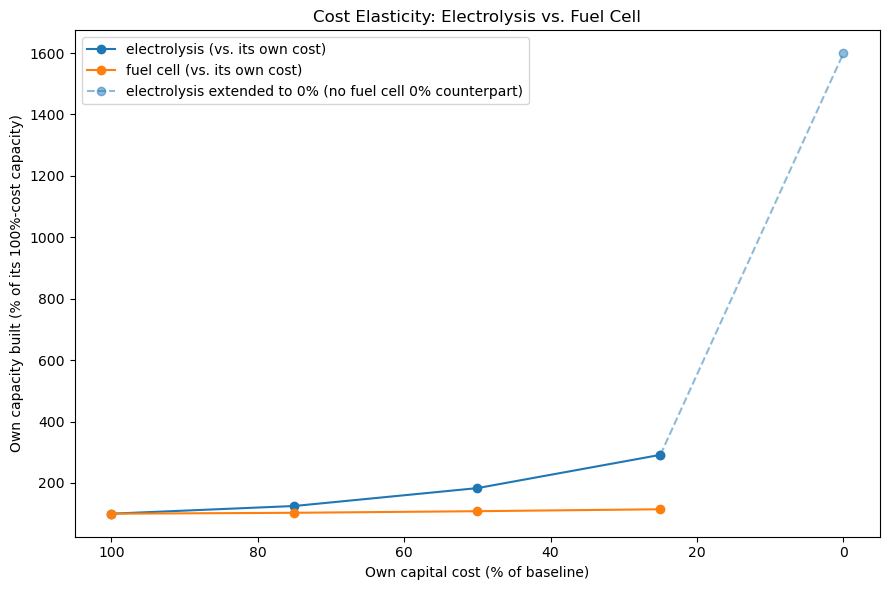

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

# common range (100-25%): direct, fair comparison
common_normalized = normalized_response.loc[common_levels]
ax.plot(common_normalized.index, common_normalized.iloc[:, 0], marker="o", label="electrolysis (vs. its own cost)")
ax.plot(common_normalized.index, common_normalized.iloc[:, 1], marker="o", label="fuel cell (vs. its own cost)")

# electrolysis-only 0% point: extended reference, not a fair fuel-cell comparison
if 0 in electrolysis_capacity.index:
    ax.plot(
        [25, 0],
        [normalized_response.loc[25].iloc[0], normalized_response.loc[0].iloc[0]],
        marker="o", linestyle="--", color="tab:blue", alpha=0.5,
        label="electrolysis extended to 0% (no fuel cell 0% counterpart)",
    )

ax.set_xlabel("Own capital cost (% of baseline)")
ax.set_ylabel("Own capacity built (% of its 100%-cost capacity)")
ax.set_title("Cost Elasticity: Electrolysis vs. Fuel Cell")
ax.invert_xaxis()
ax.legend()

fig.tight_layout()
savefig(fig, "pypsa/h2_comparison", "cost_elasticity.png")
plt.show()

## 2. Total System Cost Savings

In [6]:
electrolysis_cost = pd.Series(
    {level: total_system_cost(net, cost_scale) for level, net in electrolysis_sweep.items()}
).sort_index(ascending=False)
fuel_cell_cost = pd.Series(
    {level: total_system_cost(net, cost_scale) for level, net in fuel_cell_sweep.items()}
).sort_index(ascending=False)

cost_comparison = pd.DataFrame({
    "electrolysis sweep total cost (EUR/yr)": electrolysis_cost,
    "fuel cell sweep total cost (EUR/yr)": fuel_cell_cost,
})
cost_comparison.index.name = "cost level (% of baseline)"
cost_comparison

,electrolysis sweep total cost (EUR/yr),fuel cell sweep total cost (EUR/yr)
cost level (% of baseline),,
0,7.049024e+09,NaN
25,7.444807e+09,6.457322e+09
50,7.657434e+09,6.956343e+09
75,7.790833e+09,7.430476e+09
100,7.883553e+09,7.883553e+09


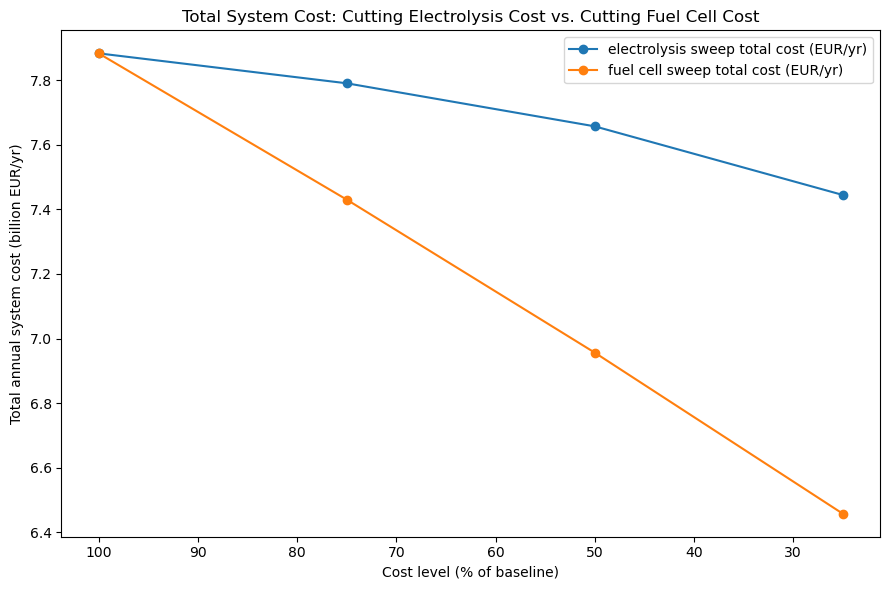

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

(cost_comparison.loc[common_levels] / 1e9).plot(marker="o", ax=ax)

ax.set_xlabel("Cost level (% of baseline)")
ax.set_ylabel("Total annual system cost (billion EUR/yr)")
ax.set_title("Total System Cost: Cutting Electrolysis Cost vs. Cutting Fuel Cell Cost")
ax.invert_xaxis()

fig.tight_layout()
savefig(fig, "pypsa/h2_comparison", "total_cost_comparison.png")
plt.show()

## 3. Cross-Effects: Does Cutting One Technology's Cost Also Grow the Other?

In [8]:
cross_effect = pd.DataFrame({
    "fuel cell capacity in electrolysis sweep (MW)": own_capacity(electrolysis_sweep, "H2 fuel cell"),
    "electrolysis capacity in fuel cell sweep (MW)": own_capacity(fuel_cell_sweep, "H2 electrolysis"),
})
cross_effect.index.name = "cost level (% of baseline)"
cross_effect

,fuel cell capacity in electrolysis sweep (MW),electrolysis capacity in fuel cell sweep (MW)
cost level (% of baseline),,
0,7309.023136,NaN
25,7152.613601,2273.769763
50,6962.493100,2016.936701
75,6511.195259,1607.582204
100,6341.175921,1445.371966
